/opt/anaconda3/envs/gems_gpu/lib/python3.12/site-packages/xarray/coding/times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)


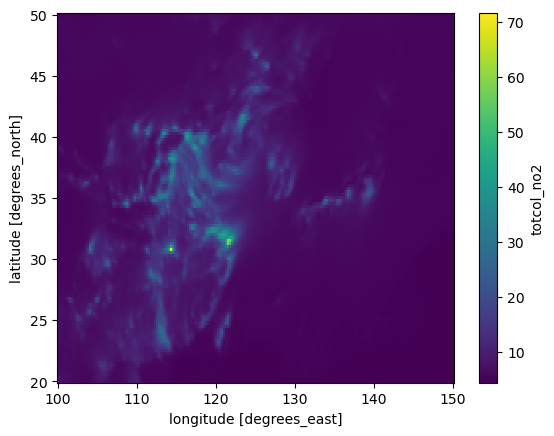

In [5]:
import xarray as xr

# 1. 데이터셋 주소 설정 (끝에 .info를 빼고 입력)
url = "https://opendap.nccs.nasa.gov/dods/gmao/geos-cf/assim/xgc_tavg_1hr_g1440x721_x1"

# 2. 데이터 오픈 (원격으로 연결만 됨, 메모리 점유 낮음)
ds = xr.open_dataset(url)

# 3. 원하는 변수와 영역 선택 (예: NO2 전층 농도, 특정 날짜, 아시아 지역)
# 변수명은 위 사이트 info에서 확인 가능 (예: 'no2' 또는 'totno2')
# 수정 전
# subset = ds['no2'].sel(...)

# 수정 후
subset = ds['totcol_no2'].sel(
    time="2022-07-07", 
    lat=slice(20, 50), 
    lon=slice(100, 150)
)

# 4. 시각화 (간단한 확인)
subset.mean(dim="time").plot()

/opt/anaconda3/envs/gems_gpu/lib/python3.12/site-packages/xarray/coding/times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)


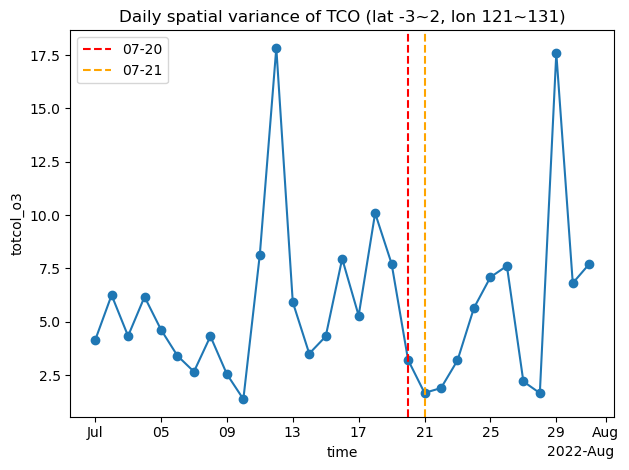

time
2022-07-01     4.131079
2022-07-02     6.250746
2022-07-03     4.332179
2022-07-04     6.169551
2022-07-05     4.628961
2022-07-06     3.403604
2022-07-07     2.660773
2022-07-08     4.321291
2022-07-09     2.543115
2022-07-10     1.371924
2022-07-11     8.152731
2022-07-12    17.838997
2022-07-13     5.922072
2022-07-14     3.505549
2022-07-15     4.314479
2022-07-16     7.956470
2022-07-17     5.289047
2022-07-18    10.092711
2022-07-19     7.722174
2022-07-20     3.212555
2022-07-21     1.665164
2022-07-22     1.893046
2022-07-23     3.187864
2022-07-24     5.648764
2022-07-25     7.089670
2022-07-26     7.619464
2022-07-27     2.201534
2022-07-28     1.655630
2022-07-29    17.592249
2022-07-30     6.811686
2022-07-31     7.708981
Freq: D, Name: totcol_o3, dtype: float32


/opt/anaconda3/envs/gems_gpu/lib/python3.12/site-packages/xarray/coding/times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)


KeyError: "No variable named 'PRECTOT'. Variables on the dataset include ['zl', 'zpbl', 'ps', 'v2m', 'v', ..., 'rh', 'time', 'lev', 'lat', 'lon']"

In [8]:
import xarray as xr       
import pandas as pd                                                                                
import numpy as np                                                                                        
import matplotlib.pyplot as plt                                                                         

# ── 1. TCO spatial variance (모든 7월 날짜 비교) ──────────────────────────                              
url_chem = "https://opendap.nccs.nasa.gov/dods/gmao/geos-cf/assim/xgc_tavg_1hr_g1440x721_x1"
ds_chem = xr.open_dataset(url_chem)                                                                       
                
tco = ds_chem['totcol_o3'].sel(                                                                           
    time=slice("2022-07-01", "2022-07-31"),
    lat=slice(-3, 2),                                                                                     
    lon=slice(121, 131)
)  # [time, lat, lon]
                                                                                                        
# daily spatial variance
tco_daily = tco.resample(time="1D").mean()  # 일평균                                                      
daily_var = tco_daily.var(dim=["lat", "lon"])  # 하루마다 공간 분산                                       
                                                                                                        
daily_var.plot(marker='o')                                                                                
plt.axvline(pd.Timestamp("2022-07-20"), color='r', linestyle='--', label='07-20')                         
plt.axvline(pd.Timestamp("2022-07-21"), color='orange', linestyle='--', label='07-21')                    
plt.title("Daily spatial variance of TCO (lat -3~2, lon 121~131)")                                        
plt.legend(); plt.tight_layout(); plt.show()                                                              
print(daily_var.to_pandas())                                                                              
                                                                                                        
# ── 2. 강수량으로 날씨 확인 ───────────────────────────────────────────────                              
url_met = "https://opendap.nccs.nasa.gov/dods/gmao/geos-cf/assim/met_tavg_1hr_g1440x721_x1"
ds_met = xr.open_dataset(url_met)                                                                         
                
# 강수량 (PRECTOT 또는 PRECCU)                                                                            
precip = ds_met['PRECTOT'].sel(
    time=slice("2022-07-01", "2022-07-31"),                                                               
    lat=slice(-3, 2),                                                                                     
    lon=slice(121, 131)
)                                                                                                         



precip_daily = precip.resample(time="1D").sum()                                                           
precip_spatial_mean = precip_daily.mean(dim=["lat", "lon"])
                                                                                                        
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)                                              
daily_var.plot(ax=axes[0], marker='o')
axes[0].axvline(pd.Timestamp("2022-07-20"), color='r', linestyle='--')                                    
axes[0].axvline(pd.Timestamp("2022-07-21"), color='orange', linestyle='--')
axes[0].set_title("TCO spatial variance")                                                                 
                
precip_spatial_mean.plot(ax=axes[1], marker='o', color='steelblue')                                       
axes[1].axvline(pd.Timestamp("2022-07-20"), color='r', linestyle='--', label='07-20')
axes[1].axvline(pd.Timestamp("2022-07-21"), color='orange', linestyle='--', label='07-21')                
axes[1].set_title("Domain-mean precipitation")                                                            
axes[1].legend()
plt.tight_layout(); plt.show()               
  

['zl', 'zpbl', 'ps', 'v2m', 'v', 'q2m', 'u', 't2m', 'troppb', 'q', 't', 'v10m', 't10m', 'u2m', 'q10m', 'ts', 'slp', 'cldtt', 'phis', 'tprec', 'u10m', 'rh']


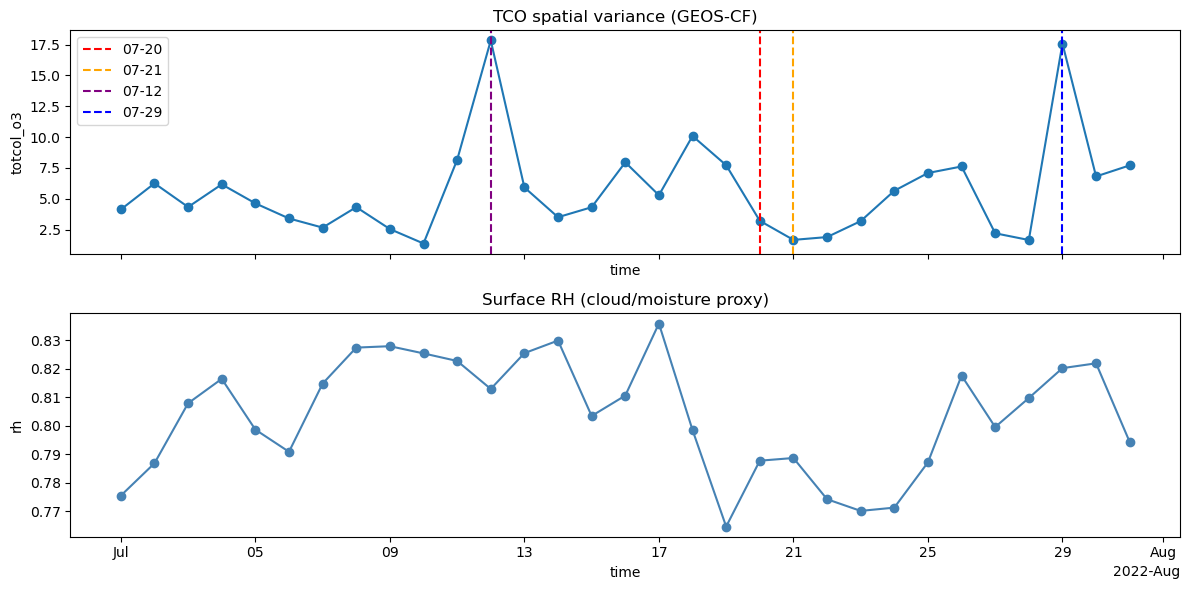

In [9]:
# 사용 가능한 변수 확인
print(list(ds_met.data_vars))

# 상대습도(rh)로 cloud/moist 조건 proxy
rh = ds_met['rh'].sel(
    time=slice("2022-07-01", "2022-07-31"),
    lat=slice(-3, 2),
    lon=slice(121, 131),
    lev=ds_met['lev'].values[-1]  # 지표 근처 레벨
)

rh_daily = rh.resample(time="1D").mean()
rh_spatial_mean = rh_daily.mean(dim=["lat", "lon"])

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
daily_var.plot(ax=axes[0], marker='o')
for d, c in [("2022-07-20", 'r'), ("2022-07-21", 'orange'),
            ("2022-07-12", 'purple'), ("2022-07-29", 'blue')]:
    axes[0].axvline(pd.Timestamp(d), color=c, linestyle='--', label=d[5:])
axes[0].set_title("TCO spatial variance (GEOS-CF)")
axes[0].legend()

rh_spatial_mean.plot(ax=axes[1], marker='o', color='steelblue')
axes[1].set_title("Surface RH (cloud/moisture proxy)")
plt.tight_layout(); plt.show()

Nice to hear from you! It’s great to know you’re making progress with the GEMS data. The enhanced ozone variability around noon may reflect stronger photochemical activity driven by peak UV radiation near solar noon. In fact, I would generally expect data quality from GEMS to be better at that time of day, so instrumental error is unlikely to be the primary cause.

To assess whether this behavior is physically expected, you could perform a similar analysis using chemical transport model simulations and compare the diurnal variability patterns with your GEMS results. I’d recommend using NASA’s GEOS-CF simulations, which are relatively easy to access and work with. Total column data can be found here:
https://opendap.nccs.nasa.gov/dods/gmao/geos-cf/assim/xgc_tavg_1hr_g1440x721_x1.info

/opt/anaconda3/envs/gems_gpu/lib/python3.12/site-packages/xarray/coding/times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)


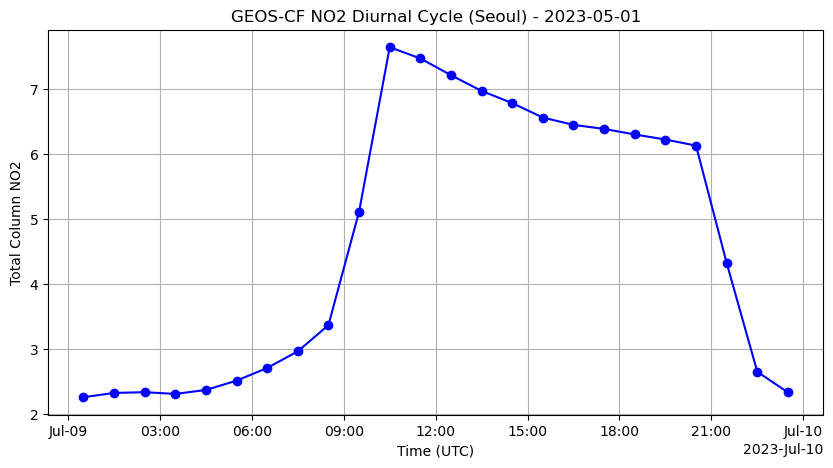

In [2]:
import xarray as xr
import matplotlib.pyplot as plt

# 데이터셋 연결
url = "https://opendap.nccs.nasa.gov/dods/gmao/geos-cf/assim/xgc_tavg_1hr_g1440x721_x1"
ds = xr.open_dataset(url)
target_var = 'totcol_no2'

# 1. 공간과 시간 범위 동시 선택 (2023년 5월 1일 하루 전체, 서울 지점)
# slice 대신 특정 위경도를 주고 method="nearest"를 사용해 해당 지점의 데이터를 가져옵니다.
diurnal_data = ds[target_var].sel(
    lat=0.5, 
    lon=127.0, 
    method="nearest"
).sel(
    time=slice("2023-07-09T00:00:00", "2023-07-09T23:59:59")
)

# 2. 일변화 시계열 그래프 그리기
plt.figure(figsize=(10, 5))
diurnal_data.plot(marker='o', linestyle='-', color='b')
plt.title("GEOS-CF NO2 Diurnal Cycle (Seoul) - 2023-05-01")
plt.xlabel("Time (UTC)")
plt.ylabel("Total Column NO2")
plt.grid(True)
plt.show()

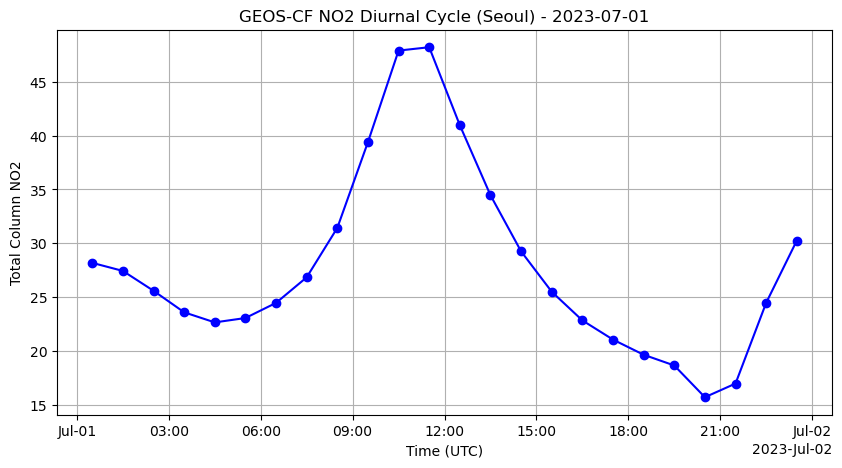

In [6]:
diurnal_data = ds[target_var].sel(
    lat=37.5, 
    lon=127.0, 
    method="nearest"
).sel(
    time=slice("2023-07-01T00:00:00", "2023-07-01T23:59:59")
)

# 2. 일변화 시계열 그래프 그리기
plt.figure(figsize=(10, 5))
diurnal_data.plot(marker='o', linestyle='-', color='b')
plt.title("GEOS-CF NO2 Diurnal Cycle (Seoul) - 2023-07-01")
plt.xlabel("Time (UTC)")
plt.ylabel("Total Column NO2")
plt.grid(True)
plt.show()

/opt/anaconda3/envs/gems_gpu/lib/python3.12/site-packages/xarray/coding/times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)


NASA 서버에서 데이터를 한 번에 다운로드합니다. 잠시만 기다려주세요...
다운로드 완료! 눈 깜짝할 새 연산하고 그래프를 그립니다.


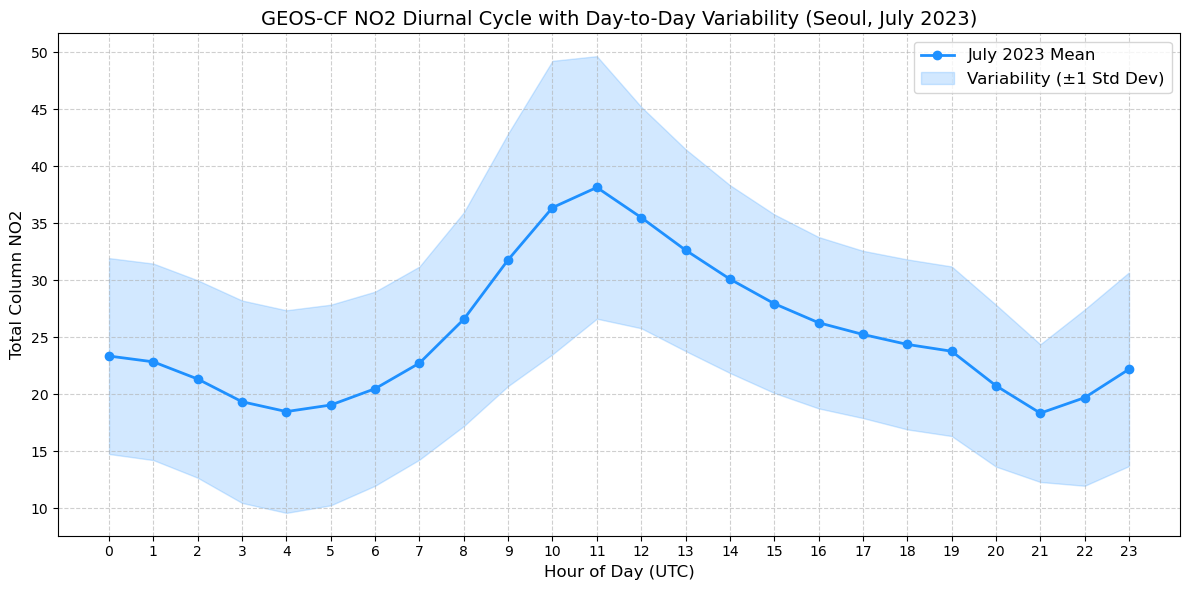

In [11]:
import xarray as xr
import matplotlib.pyplot as plt

# 데이터셋 연결
url = "https://opendap.nccs.nasa.gov/dods/gmao/geos-cf/assim/xgc_tavg_1hr_g1440x721_x1"
ds = xr.open_dataset(url)
target_var = 'totcol_no2'

print("NASA 서버에서 데이터를 한 번에 다운로드합니다. 잠시만 기다려주세요...")

# 1. 한 달치 데이터 가져오기 및 메모리 적재 (.load() 추가)
subset = ds[target_var].sel(
    lat=37.5, # 서울 위도
    lon=127.0, 
    method="nearest"
).sel(
    time=slice("2023-07-01", "2023-07-31")
).load() # <--- 통신 병목을 없애는 최적화 코드

print("다운로드 완료! 눈 깜짝할 새 연산하고 그래프를 그립니다.")

# 2. 시간대(hour)별로 데이터를 묶어서 평균(mean)과 변동성(std) 계산
hourly_mean = subset.groupby(subset.time.dt.hour).mean()
hourly_std = subset.groupby(subset.time.dt.hour).std()

# X축과 Y축 값 추출
hours_utc = hourly_mean.hour.values
mean_values = hourly_mean.values
std_values = hourly_std.values

# 3. 그래프 그리기
plt.figure(figsize=(12, 6))

# 평균값 선 그래프
plt.plot(hours_utc, mean_values, marker='o', linestyle='-', color='dodgerblue', linewidth=2, label='July 2023 Mean')

# 변동성(표준편차) 음영 처리
plt.fill_between(hours_utc, 
                 mean_values - std_values, 
                 mean_values + std_values, 
                 color='dodgerblue', alpha=0.2, label='Variability (±1 Std Dev)')

# 그래프 꾸미기
plt.title("GEOS-CF NO2 Diurnal Cycle with Day-to-Day Variability (Seoul, July 2023)", fontsize=14)
plt.xlabel("Hour of Day (UTC)", fontsize=12)
plt.ylabel("Total Column NO2", fontsize=12)
plt.xticks(hours_utc) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

/opt/anaconda3/envs/gems_gpu/lib/python3.12/site-packages/xarray/coding/times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)


NASA 서버에서 데이터를 한 번에 다운로드합니다. 잠시만 기다려주세요...
다운로드 완료! 눈 깜짝할 새 연산하고 그래프를 그립니다.


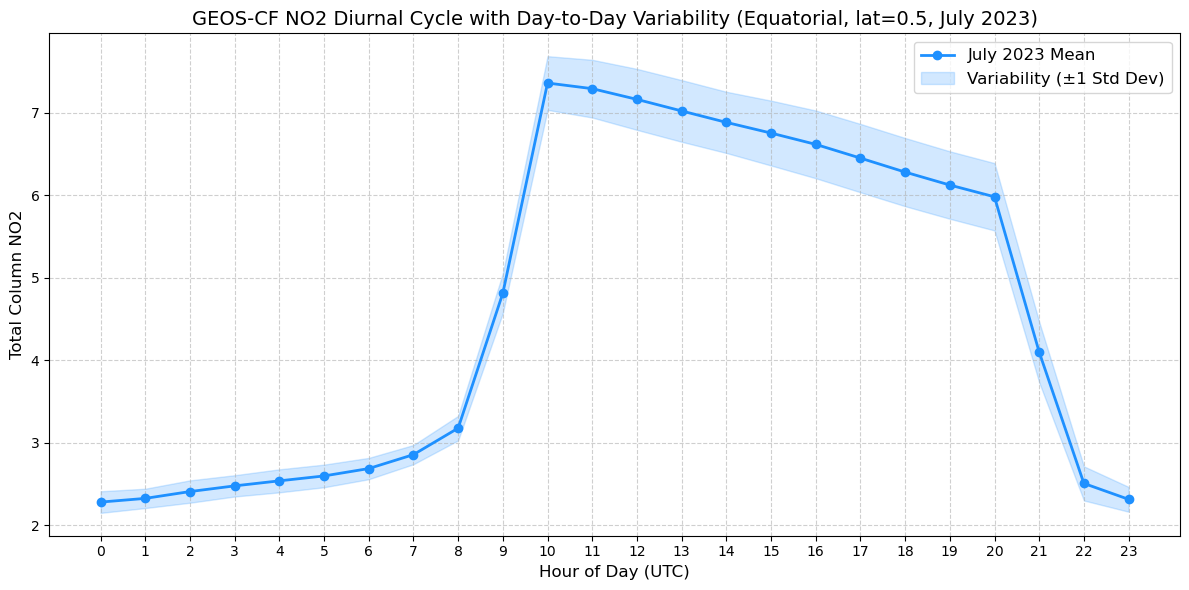

In [8]:
import xarray as xr
import matplotlib.pyplot as plt

# 데이터셋 연결
url = "https://opendap.nccs.nasa.gov/dods/gmao/geos-cf/assim/xgc_tavg_1hr_g1440x721_x1"
ds = xr.open_dataset(url)
target_var = 'totcol_no2'

print("NASA 서버에서 데이터를 한 번에 다운로드합니다. 잠시만 기다려주세요...")

# 1. 한 달치 데이터 가져오기 및 메모리 적재 (.load() 추가)
subset = ds[target_var].sel(
    lat=0.5, # 
    lon=127.0, 
    method="nearest"
).sel(
    time=slice("2023-07-01", "2023-07-31")
).load() # <--- 통신 병목을 없애는 최적화 코드

print("다운로드 완료! 눈 깜짝할 새 연산하고 그래프를 그립니다.")

# 2. 시간대(hour)별로 데이터를 묶어서 평균(mean)과 변동성(std) 계산
hourly_mean = subset.groupby(subset.time.dt.hour).mean()
hourly_std = subset.groupby(subset.time.dt.hour).std()

# X축과 Y축 값 추출
hours_utc = hourly_mean.hour.values
mean_values = hourly_mean.values
std_values = hourly_std.values

# 3. 그래프 그리기
plt.figure(figsize=(12, 6))

# 평균값 선 그래프
plt.plot(hours_utc, mean_values, marker='o', linestyle='-', color='dodgerblue', linewidth=2, label='July 2023 Mean')

# 변동성(표준편차) 음영 처리
plt.fill_between(hours_utc, 
                 mean_values - std_values, 
                 mean_values + std_values, 
                 color='dodgerblue', alpha=0.2, label='Variability (±1 Std Dev)')

# 그래프 꾸미기
plt.title("GEOS-CF NO2 Diurnal Cycle with Day-to-Day Variability (Equatorial, lat=0.5, July 2023)", fontsize=14)
plt.xlabel("Hour of Day (UTC)", fontsize=12)
plt.ylabel("Total Column NO2", fontsize=12)
plt.xticks(hours_utc) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

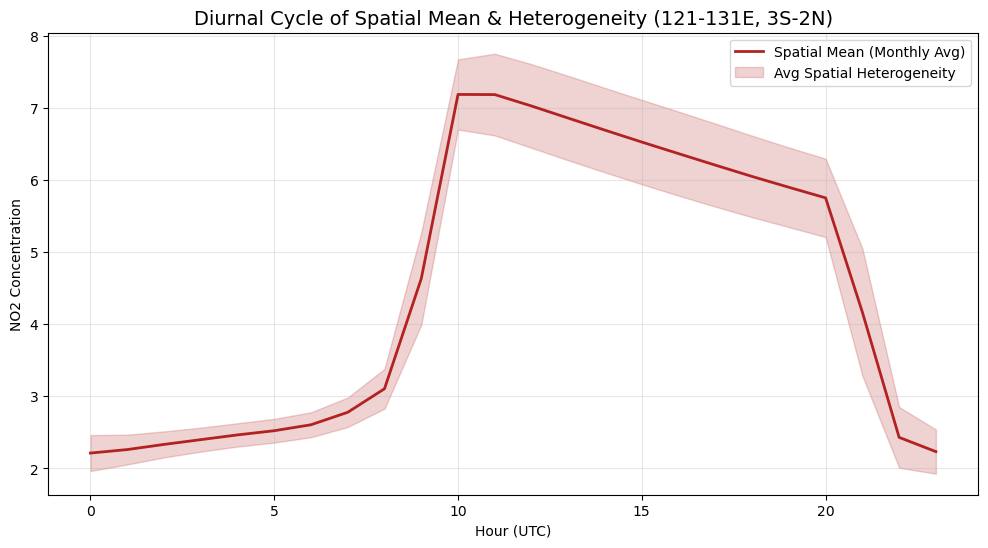

In [9]:
# 1. 공간 범위 지정 및 데이터 로드 (Slice 사용)
spatial_subset = ds[target_var].sel(
    lat=slice(-3, 2),     # 위도 범위
    lon=slice(121, 131)   # 경도 범위
).sel(
    time=slice("2023-07-01", "2023-07-31")
).load()

# 2. 각 시점(time)별로 공간 평균과 공간 표준편차 계산
# dim=['lat', 'lon']을 지정하면 공간 축으로 압축됩니다.
space_mean_ts = spatial_subset.mean(dim=['lat', 'lon'])
space_std_ts = spatial_subset.std(dim=['lat', 'lon'])

# 3. 시간대(hour)별로 그룹화하여 한 달간의 평균적 다이어널 패턴 계산
# 공간 평균들의 시간대별 평균
diurnal_mean = space_mean_ts.groupby(space_mean_ts.time.dt.hour).mean()

# "공간적 불균질성(Spatial Heterogeneity)"의 시간대별 평균
# 질문하신 '시간대별 분산 구하고 다른 요일 같은 시간대에 대해 평균'하는 로직입니다.
diurnal_spatial_spread = space_std_ts.groupby(space_std_ts.time.dt.hour).mean()

# 그래프 그리기
hours = diurnal_mean.hour.values
plt.figure(figsize=(12, 6))

# 선: 공간 평균의 다이어널 패턴
plt.plot(hours, diurnal_mean.values, color='firebrick', lw=2, label='Spatial Mean (Monthly Avg)')

# 음영: 해당 시간대에 기대되는 '공간적 변동성'의 크기
plt.fill_between(hours, 
                 diurnal_mean.values - diurnal_spatial_spread.values, 
                 diurnal_mean.values + diurnal_spatial_spread.values, 
                 color='firebrick', alpha=0.2, label='Avg Spatial Heterogeneity')

plt.title("Diurnal Cycle of Spatial Mean & Heterogeneity (121-131E, 3S-2N)", fontsize=14)
plt.xlabel("Hour (UTC)")
plt.ylabel("NO2 Concentration")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

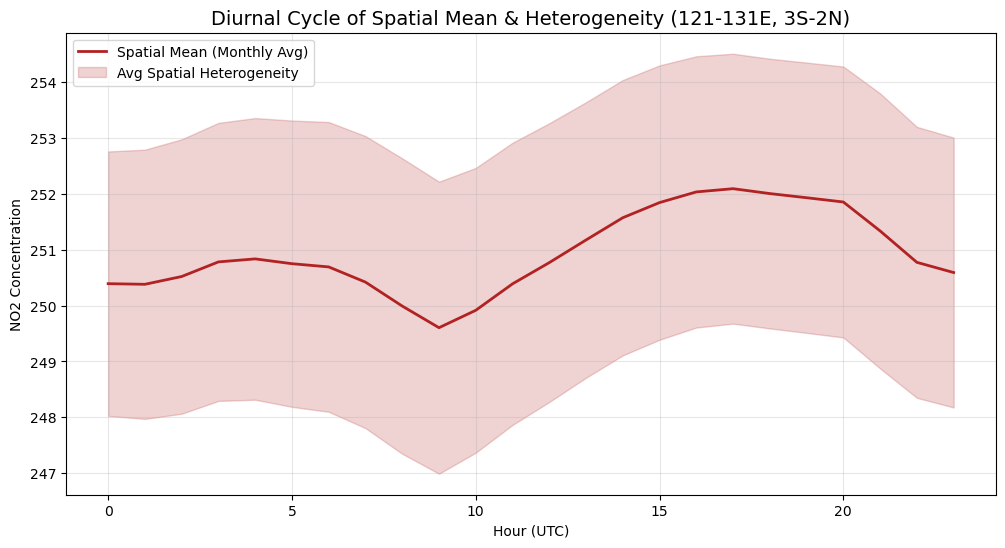

In [ ]:
# 1. 공간 범위 지정 및 데이터 로드 (Slice 사용)
target_var = 'totcol_o3'
spatial_subset = ds[target_var].sel(
    lat=slice(-3, 2),     # 위도 범위
    lon=slice(121, 131)   # 경도 범위
).sel(
    time=slice("2022-07-01", "2023-07-31")
).load()

# 2. 각 시점(time)별로 공간 평균과 공간 표준편차 계산
# dim=['lat', 'lon']을 지정하면 공간 축으로 압축됩니다.
space_mean_ts = spatial_subset.mean(dim=['lat', 'lon'])
space_std_ts = spatial_subset.std(dim=['lat', 'lon'])

# 3. 시간대(hour)별로 그룹화하여 한 달간의 평균적 다이어널 패턴 계산
# 공간 평균들의 시간대별 평균
diurnal_mean = space_mean_ts.groupby(space_mean_ts.time.dt.hour).mean()

# "공간적 불균질성(Spatial Heterogeneity)"의 시간대별 평균
# 질문하신 '시간대별 분산 구하고 다른 요일 같은 시간대에 대해 평균'하는 로직입니다.
diurnal_spatial_spread = space_std_ts.groupby(space_std_ts.time.dt.hour).mean()

# 그래프 그리기
hours = diurnal_mean.hour.values
plt.figure(figsize=(12, 6))

# 선: 공간 평균의 다이어널 패턴
plt.plot(hours, diurnal_mean.values, color='firebrick', lw=2, label='Spatial Mean (Monthly Avg)')

# 음영: 해당 시간대에 기대되는 '공간적 변동성'의 크기
plt.fill_between(hours, 
                 diurnal_mean.values - diurnal_spatial_spread.values, 
                 diurnal_mean.values + diurnal_spatial_spread.values, 
                 color='firebrick', alpha=0.2, label='Avg Spatial Heterogeneity')

plt.title("Diurnal Cycle of Spatial Mean & Heterogeneity (121-131E, 3S-2N)", fontsize=14)
plt.xlabel("Hour (UTC)")
plt.ylabel("NO2 Concentration")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## GEMS TCO — Diurnal Spatial Heteroscedasticity (July 2024)

**방법론:**
- 각 (day d, slot t): 격자 전체의 공간값 Y(s,d,t) 로드
- Per-day demean: Ỹ(s,d,t) = Y(s,d,t) − μ(d,t),  μ(d,t) = mean over all slots × all spatial obs for day d time t
- Per-slot: σ²(t) = mean_d[ Var_s[ Ỹ(s,d,t) ] ]
- σ̂(t) = √σ²(t) → GP heteroscedasticity scaling factor for Y(s,t) = μ(t) + σ(t)·Z(s,t)


--- Global Monthly Mean for 2024-7: 257.9726 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
July 2024: 31 days

Per-slot σ̂(t)  [r(s,t,d) = Y(s,t,d) - ȳ(t,d), pooled across days]
 slot      hour_utc  n_residuals  mean_ybar  sigma_t     var_t
    0 478080.883333       560025 258.419048 3.718556 13.827656
    1 478081.883333       548961 257.925795 3.967329 15.739700
    2 478082.883333       532699 257.159922 4.042988 16.345754
    3 478083.883333       533609 256.918535 4.101558 16.822778
    4 478084.800000       536310 257.100139 4.095244 16.771024
    5 478085.800000       548958 257.773135 4.195926 17.605799
    6 478086.800000       561073 258.301764 3.879166 15.047930
    7 478087.800000       560965 260.281265 3.645356 13.288623

Max/Min σ̂(t) ratio : 1.15×   (variance ratio: 1.3×)


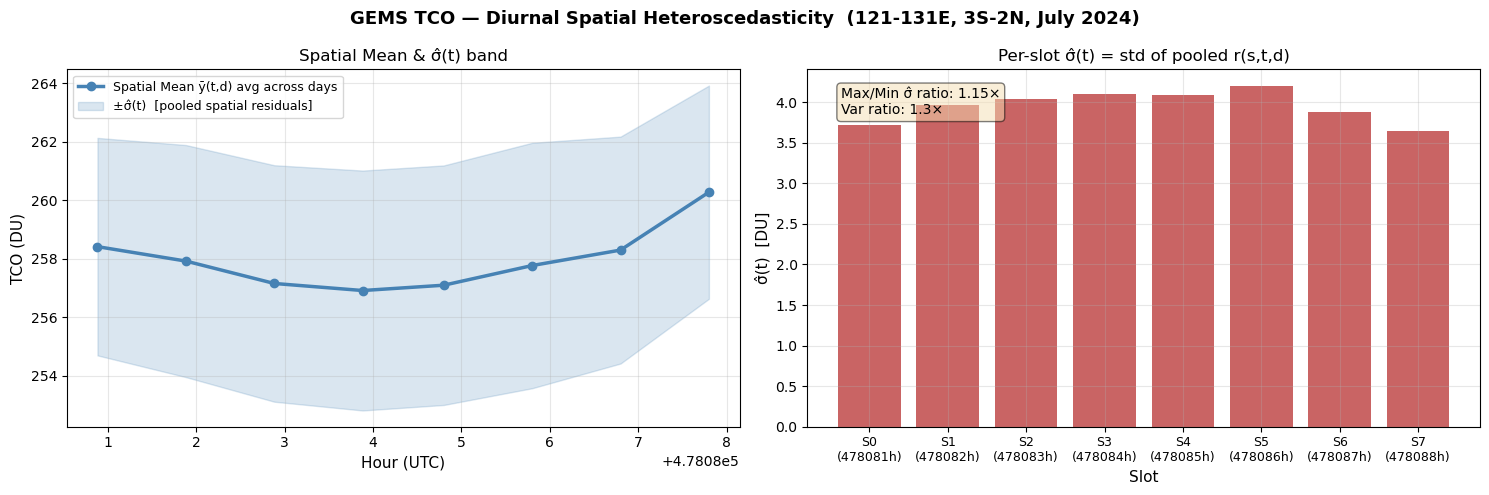

Plot saved.


In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("/Users/joonwonlee/Documents/GEMS_TCO-1/src")
from GEMS_TCO import configuration as config
from GEMS_TCO.data_loader import load_data_dynamic_processed

YEAR      = '2024'
MONTH     = 7
LAT_RANGE = [-3.0, 2.0]
LON_RANGE = [121.0, 131.0]

data_loader = load_data_dynamic_processed(config.mac_data_load_path)
df_map, _, _, _ = data_loader.load_maxmin_ordered_data_bymonthyear(
    lat_lon_resolution=[1, 1], mm_cond_number=10,
    years_=[YEAR], months_=[MONTH],
    lat_range=LAT_RANGE, lon_range=LON_RANGE,
    is_whittle=False
)
sorted_keys = sorted(df_map.keys())
n_days = len(sorted_keys) // 8
print(f"July {YEAR}: {n_days} days")

# Model:  Y(s,t,d) = mu(t,d) + sigma(t) * Z(s,t,d)
# Demean: r(s,t,d) = Y(s,t,d) - y_bar(t,d)   where y_bar(t,d) = mean_s Y(s,t,d)
# sigma^2(t) = Var over (s,d) of r(s,t,d)   [pool 30 days per slot]

# Collect: slot -> list of all r(s,t,d) residuals across all days
slot_residuals  = {t: [] for t in range(8)}   # pooled r(s,t,d) across days
slot_smeans     = {t: [] for t in range(8)}   # y_bar(t,d) per day (for mean plot)
slot_hours      = {t: [] for t in range(8)}   # hour (UTC) per (t,d)

for d_idx in range(n_days):
    day_keys = sorted_keys[d_idx * 8 : (d_idx + 1) * 8]

    for slot, key in enumerate(day_keys):
        df    = df_map[key]
        o3    = pd.to_numeric(df['ColumnAmountO3'], errors='coerce').dropna().values
        hours = pd.to_numeric(df['Hours_elapsed'],  errors='coerce').dropna()
        if len(o3) == 0:
            continue

        y_bar_td = o3.mean()                 # spatial mean at this (t, d)
        r_td     = o3 - y_bar_td             # r(s, t, d) = Y - y_bar(t,d)

        slot_residuals[slot].extend(r_td.tolist())
        slot_smeans[slot].append(y_bar_td)
        slot_hours[slot].append(float(hours.median()))

# Per-slot summary
rows = []
for t in range(8):
    r   = np.array(slot_residuals[t])
    m   = np.array(slot_smeans[t])
    h   = np.array(slot_hours[t])
    rows.append({
        'slot'         : t,
        'hour_utc'     : h.mean(),
        'n_residuals'  : len(r),
        'n_days'       : len(m),
        'mean_ybar'    : m.mean(),              # diurnal cycle of spatial mean
        'sigma_t'      : r.std(ddof=1),         # sigma(t) = std of pooled r(s,t,d)
        'var_t'        : r.var(ddof=1),         # sigma^2(t)
    })

df_slot = pd.DataFrame(rows)
ratio = df_slot['sigma_t'].max() / df_slot['sigma_t'].min()

print("\nPer-slot σ̂(t)  [r(s,t,d) = Y(s,t,d) - ȳ(t,d), pooled across days]")
print(df_slot[['slot','hour_utc','n_residuals','mean_ybar','sigma_t','var_t']].to_string(index=False))
print(f"\nMax/Min σ̂(t) ratio : {ratio:.2f}×   (variance ratio: {ratio**2:.1f}×)")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    f"GEMS TCO — Diurnal Spatial Heteroscedasticity  (121-131E, 3S-2N, July {YEAR})",
    fontsize=13, fontweight='bold'
)
hours = df_slot['hour_utc'].values

# Panel 1: Spatial Mean & Heterogeneity (GEOS-CF 스타일)
ax = axes[0]
ax.plot(hours, df_slot['mean_ybar'].values,
        color='steelblue', lw=2.5, marker='o', label='Spatial Mean ȳ(t,d) avg across days')
sigma = df_slot['sigma_t'].values
ax.fill_between(hours,
                df_slot['mean_ybar'].values - sigma,
                df_slot['mean_ybar'].values + sigma,
                color='steelblue', alpha=0.2, label='±σ̂(t)  [pooled spatial residuals]')
ax.set_xlabel("Hour (UTC)", fontsize=11)
ax.set_ylabel("TCO (DU)", fontsize=11)
ax.set_title("Spatial Mean & σ̂(t) band")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 2: σ̂(t) bar chart
ax2 = axes[1]
ax2.bar(range(8), df_slot['sigma_t'].values, color='firebrick', alpha=0.7)
ax2.set_xticks(range(8))
ax2.set_xticklabels([f"S{i}\n({h:.0f}h)" for i, h in enumerate(hours)], fontsize=9)
ax2.set_xlabel("Slot", fontsize=11)
ax2.set_ylabel("σ̂(t)  [DU]", fontsize=11)
ax2.set_title("Per-slot σ̂(t) = std of pooled r(s,t,d)")
ax2.grid(True, alpha=0.3)
ax2.text(0.05, 0.95, f"Max/Min σ̂ ratio: {ratio:.2f}×\nVar ratio: {ratio**2:.1f}×",
         transform=ax2.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(
    '/Users/joonwonlee/Documents/GEMS_TCO-1/outputs/gems_tco_diurnal_sigma_july2024.png',
    dpi=130, bbox_inches='tight'
)
plt.show()
print("Plot saved.")
